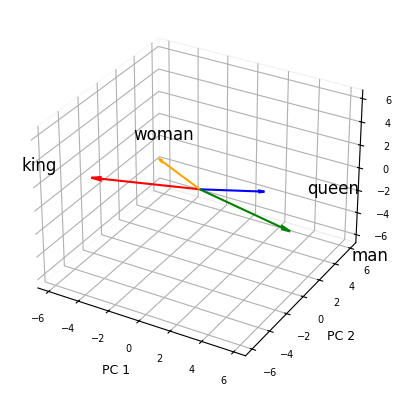

In [4]:
import json
import numpy as np
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import os
os.makedirs("pca3D", exist_ok=True)


"""
This file cretaes a 3D plot of an iteration.json file using pyplot quiver. This file is the one used to create images in
"3D_Plots" folder. Must have an iteration .json file, filepath, and labels as inputs.
"""
labels = ["king", "queen", "man", "woman"]
filepath = f"pca3D/kqmw_3D.png"
iteration = '../data/indiv_word_representations/generate_vector_from_iterative_vectors.json'

def plot(labels, iteration, filepath):
    with open(f'{iteration}', 'r') as f:
        iterations = json.load(f)

    #Extract last iterations
    last_iterations = {}
    flattened = []
    for name in labels:
        last_iterations[name] = np.array(iterations[name][-1])
        flattened.append(last_iterations[name])

    pca = PCA(n_components=3)
    vectors = pca.fit_transform(flattened)

    # Create a 3D figure
    fig = plt.figure()
    ax = fig.add_subplot(111, projection='3d')
    ax.xaxis.pane.set_facecolor((1.0, 1.0, 1.0, 1.0))  # white
    ax.yaxis.pane.set_facecolor((1.0, 1.0, 1.0, 1.0))
    ax.zaxis.pane.set_facecolor((1.0, 1.0, 1.0, 1.0))
    
    origin = np.zeros(3)
    colors = {labels[0]: "red", labels[1]: "blue", labels[2]: "green", labels[3]: "orange"}

    index = 0
    vec_mag = 0
    for vec in vectors:
        ax.quiver(
            origin[0], origin[1], origin[2],
            vec[0], vec[1], vec[2],
            color=colors[labels[index]], length=1.0, normalize=False, arrow_length_ratio=0.1
        )
        ax.text(vec[0] * 1.65, vec[1] * 1.65, vec[2] * 1.65, labels[index], color='black', fontsize=12)
        index += 1
        if vec_mag < np.linalg.norm(vec):
            vec_mag = np.linalg.norm(vec)
        else:
            continue

    ax.set_xlim(-vec_mag - 0.25, vec_mag + 0.25)
    ax.set_ylim(-vec_mag - 0.25, vec_mag + 0.25)
    ax.set_zlim(-vec_mag - 0.25, vec_mag + 0.25)

    ax.tick_params(labelsize=7) 

    ax.set_xlabel('PC 1', fontsize=9)
    ax.set_ylabel('PC 2', fontsize=9)
    ax.set_zlabel('PC 3', fontsize=9)

    plt.savefig(filepath, dpi = 300)
    plt.show()





plot(labels, iteration, filepath)